### Connect to Chroma DB 

In [1]:
import chromadb
import re
import unicodedata
import requests
import psycopg
from sqlalchemy import create_engine, text
from striprtf.striprtf import rtf_to_text
import pandas as pd

chroma_client = chromadb.HttpClient(host='localhost', port=8000)
chroma_client.heartbeat()

collections = chroma_client.list_collections()

In [2]:
collections

[Collection(name=new_gen_docs)]

In [52]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("google/embeddinggemma-300m")

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 994.91it/s, Materializing param=norm.weight]                                 


In [55]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

ef = SentenceTransformerEmbeddingFunction(model_name="google/embeddinggemma-300m")

Loading weights: 100%|██████████| 314/314 [00:00<00:00, 1227.97it/s, Materializing param=norm.weight]                                


In [ ]:
chroma_client.delete_collection(name="new_gen_docs")
# from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

# collection = chroma_client.get_or_create_collection( # create_collection
#     name="new_gen_docs",
#     embedding_function=OpenAIEmbeddingFunction(
#         api_key=
#         model_name="text-embedding-3-large"
#     )
# )

In [ ]:
import chromadb.utils.embedding_functions as embedding_functions
huggingface_ef = embedding_functions.HuggingFaceEmbeddingFunction(
    api_key="",
    model_name="google/embeddinggemma-300m"
)

In [57]:
collection = chroma_client.get_or_create_collection( # create_collection
    name="new_gen_docs",
    embedding_function=ef#model#huggingface_ef
)

In [4]:
collection.peek()

{'ids': ['doc_0',
  'doc_1',
  'doc_2',
  'doc_3',
  'doc_4',
  'doc_5',
  'doc_6',
  'doc_7',
  'doc_8',
  'doc_9'],
 'embeddings': array([[-0.01119294, -0.03249012, -0.00694207, ..., -0.01037947,
          0.00257805, -0.01525421],
        [ 0.00825303, -0.01016345, -0.00650817, ..., -0.00826576,
          0.00783273,  0.00164137],
        [-0.00433413, -0.01680686, -0.00120464, ..., -0.01728484,
         -0.00181019, -0.01107754],
        ...,
        [-0.02506783, -0.01283301, -0.00650997, ..., -0.02291809,
         -0.00858961, -0.02129176],
        [-0.00244707, -0.04326052, -0.00986633, ..., -0.013031  ,
         -0.01431609, -0.02839197],
        [ 0.0188541 , -0.01079861, -0.00647788, ..., -0.00891191,
         -0.0005083 , -0.03487494]], shape=(10, 3072)),
 'metadatas': [{'judge': 'Олійник І. В.',
   'adjudication_date': '2025-01-02 00:00:00+02',
   'justice_kind': 1.0,
   'court_code': 227,
   'cause_num': '149/4141/24',
   'category_code': 40356.0,
   'start_index': 0,
   '

### Preprocessing text

In [ ]:
### Load raw rtf

from striprtf.striprtf import rtf_to_text
import glob

rtf_texts = []

for file_path in glob.glob("../chroma/data/*.rtf"):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        rtf_content = f.read()
        text = rtf_to_text(rtf_content)
        rtf_texts.append(text)

len(rtf_texts)

In [33]:
import pandas as pd

In [58]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
import re

target_words = [
  "УХВАЛА",
  "УХВАЛИВ",
  "УСТАНОВИВ",
  "ПОСТАНОВА",
  "ВСТАНОВИВ",
  "ПОСТАНОВИВ",
  "РІШЕННЯ",
  "ІМЕНЕМ",
  "УКРАЇНИ",
  "ВИРІШИВ"
]


def spaced_word_regex(word: str) -> str:
    # У\s*Х\s*В\s*А\s*Л\s*А
    return r"\b" + r"\s*".join(map(re.escape, word)) + r"\b"


def clean_text(text: str, target_words=target_words) -> str:

    if not text:
        return ""
    
    text = (
        text.replace("\xa0", " ")
            .replace("\x00", " ")
            .replace("\t", " ")
    )


    pattern = r"(?:" + r"|".join(map(spaced_word_regex, target_words)) + r")"

    text = re.sub(pattern, lambda m: re.sub(r"\s+", "", m.group(0)), text, flags=re.IGNORECASE)



    words_union = "|".join(map(re.escape, target_words))
    text = re.sub(
        rf"(?iu)\n\s*({words_union})\s*:\s*\n",
        r"\n\1: ",
        text,
    )

    text = re.sub(r'[ ]{2,}', ' ', text)

    text = re.sub(r'\n{3,}', '\n\n', text)
    text = text.strip()

    parts = text.rsplit('\n\n', 1)
    
    if len(parts) > 1:
        text = parts[0] + '\n' + parts[1]

    return text

In [59]:
def extract_rtf_text(url: str) -> str:

    response = requests.get(url)
    response.raise_for_status()

    rtf_content = response.content.decode("utf-8", errors="ignore")

    text = rtf_to_text(rtf_content)
    return text

### Load & Download

In [60]:
# # ### neon

# DATABASE_URL = (
#     "postgresql+psycopg://neondb_owner:npg_C7pw1ZRmYfTD@"
#     "ep-wandering-moon-adi9im7i-pooler.c-2.us-east-1.aws.neon.tech/neondb"
#     "?sslmode=require&channel_binding=require"
# )

# engine = create_engine(DATABASE_URL)

# with engine.connect() as conn:
#     result = conn.execute(text("SELECT 1"))
#     print(result.scalar())


# docs = pd.read_sql(
#     "SELECT * FROM documents LIMIT 10000",
#     engine
# )

docs

,Unnamed: 0,doc_id,court_code,judgment_code,justice_kind,category_code,cause_num,adjudication_date,receipt_date,judge,doc_url,status,date_publ
0,0,124212035,227,5.0,1.0,40356.0,149/4141/24,2025-01-02 00:00:00+02,2025-01-04 00:00:00+02,Олійник І. В.,http://od.reyestr.court.gov.ua/files/62/90134c...,1,2025-01-06 00:00:00+02
1,1,129579772,814,5.0,2.0,40476.0,334/6318/25,2025-08-14 00:00:00+03,2025-08-18 00:00:00+03,Турбіна Т. Ф.,http://od.reyestr.court.gov.ua/files/64/20b931...,1,2025-08-19 00:00:00+03
2,2,129526117,1521,5.0,1.0,40352.0,509/4270/25,2025-08-14 00:00:00+03,2025-08-14 00:00:00+03,Кириченко П. Л.,http://od.reyestr.court.gov.ua/files/64/5981b7...,1,2025-08-15 00:00:00+03
3,3,128243120,2029,3.0,1.0,40348.0,646/449/25,2025-06-19 00:00:00+03,2025-06-19 00:00:00+03,Черняк В. Г.,http://od.reyestr.court.gov.ua/files/64/270b13...,1,2025-06-20 00:00:00+03
4,4,126288303,5026,5.0,3.0,40222.0,925/1660/24,2025-04-02 00:00:00+03,2025-04-02 00:00:00+03,Гладун А. І.,http://od.reyestr.court.gov.ua/files/63/5821cb...,1,2025-04-03 00:00:00+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,126533719,401,5.0,1.0,41461.0,199/1472/25,2025-02-14 00:00:00+02,2025-04-11 00:00:00+03,БОГУН О. О.,http://od.reyestr.court.gov.ua/files/63/395d76...,1,2025-04-14 00:00:00+03
96,96,126677626,2011,5.0,4.0,40050.0,638/5834/25,2025-04-16 00:00:00+03,2025-04-17 00:00:00+03,Заварза Т. В.,http://od.reyestr.court.gov.ua/files/63/f3ea7c...,1,2025-04-18 00:00:00+03
97,97,126870157,2220,5.0,1.0,40377.0,688/1803/25,2025-04-25 00:00:00+03,2025-04-25 00:00:00+03,Березюк Н. П.,http://od.reyestr.court.gov.ua/files/63/cc6a41...,1,2025-04-28 00:00:00+03
98,98,125292375,444,5.0,2.0,40469.0,216/7744/23,2025-02-11 00:00:00+02,2025-02-20 00:00:00+02,ЧИРСЬКИЙ Г. М.,http://od.reyestr.court.gov.ua/files/62/c4dcce...,1,2025-02-21 00:00:00+02


In [36]:
### csv
docs = pd.read_csv("../chroma/data/docs.csv")

In [37]:
from tqdm import tqdm

### prepare texts and metadatas

all_texts = []
metadatas = []

for court_code, justice_kind, category_code, cause_num, adjudication_date, judge, doc_url, status in tqdm(docs[["court_code", "justice_kind", "category_code", "cause_num", "adjudication_date", "judge", "doc_url", "status"]].itertuples(index=False)):
    metadatas.append({"court_code": court_code, "justice_kind": justice_kind, "category_code": category_code, "cause_num": cause_num, "adjudication_date": adjudication_date, "judge": judge, "status": status})

    all_texts.append(clean_text(extract_rtf_text(doc_url)))

100it [00:10,  9.86it/s]


In [61]:
metadatas

[{'court_code': 227,
  'justice_kind': 1.0,
  'category_code': 40356.0,
  'cause_num': '149/4141/24',
  'adjudication_date': '2025-01-02 00:00:00+02',
  'judge': 'Олійник І. В.',
  'status': 1},
 {'court_code': 814,
  'justice_kind': 2.0,
  'category_code': 40476.0,
  'cause_num': '334/6318/25',
  'adjudication_date': '2025-08-14 00:00:00+03',
  'judge': 'Турбіна Т. Ф.',
  'status': 1},
 {'court_code': 1521,
  'justice_kind': 1.0,
  'category_code': 40352.0,
  'cause_num': '509/4270/25',
  'adjudication_date': '2025-08-14 00:00:00+03',
  'judge': 'Кириченко П. Л.',
  'status': 1},
 {'court_code': 2029,
  'justice_kind': 1.0,
  'category_code': 40348.0,
  'cause_num': '646/449/25',
  'adjudication_date': '2025-06-19 00:00:00+03',
  'judge': 'Черняк В. Г.',
  'status': 1},
 {'court_code': 5026,
  'justice_kind': 3.0,
  'category_code': 40222.0,
  'cause_num': '925/1660/24',
  'adjudication_date': '2025-04-02 00:00:00+03',
  'judge': 'Гладун А. І.',
  'status': 1},
 {'court_code': 370,
  

In [39]:
source_docs = [
    Document(page_content=doc, metadata=num)
    for doc, num in zip(all_texts, metadatas)
]


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=5000,
    chunk_overlap=500, 
    add_start_index=True,
    strip_whitespace=True,
    separators=["\n\n", "\n", " ", ""]
)

docs_processed = text_splitter.split_documents(source_docs)

In [63]:
from tqdm import tqdm

BATCH_SIZE = 1

for i in tqdm(range(0, len(docs_processed), BATCH_SIZE)):
    batch = docs_processed[i : i + BATCH_SIZE]
    
    collection.add(
        documents=[doc.page_content for doc in batch],
        metadatas=[doc.metadata for doc in batch],
        ids=[f"doc_{i+j}" for j in range(len(batch))]
    )

100%|██████████| 246/246 [05:41<00:00,  1.39s/it]


In [64]:
collection.count()

246

In [7]:
len(docs_processed)

NameError: name 'docs_processed' is not defined

### Other

In [65]:
from typing import List, Dict
from langchain.tools import tool

@tool
def chroma_query_documents(
    query_texts: List[str],
    n_results: int = 5,
    where: Dict | None = None,
    where_document: Dict | None = None,
    include: List[str] = ["documents", "metadatas", "distances"]
) -> Dict:
    """Query documents from a Chroma collection with advanced filtering.
    
    Args:
        query_texts: List of query texts to search for
        n_results: Number of results to return per query
        where: Optional metadata filters using Chroma's query operators
               Examples:
               - Simple equality: {"metadata_field": "value"}
               - Comparison: {"metadata_field": {"$gt": 5}}
               - Logical AND: {"$and": [{"field1": {"$eq": "value1"}}, {"field2": {"$gt": 5}}]}
               - Logical OR: {"$or": [{"field1": {"$eq": "value1"}}, {"field1": {"$eq": "value2"}}]}
        where_document: Optional document content filters
               Examples:
               - Contains: {"$contains": "value"}
               - Not contains: {"$not_contains": "value"}
               - Regex: {"$regex": "[a-z]+"}
               - Not regex: {"$not_regex": "[a-z]+"}
               - Logical AND: {"$and": [{"$contains": "value1"}, {"$not_regex": "[a-z]+"}]}
               - Logical OR: {"$or": [{"$regex": "[a-z]+"}, {"$not_contains": "value2"}]}
        include: List of what to include in response. By default, this will include documents, metadatas, and distances.
    """
    if not query_texts:
        raise ValueError("The 'query_texts' list cannot be empty.")

    # client = get_chroma_client()
    try:
        # collection = chroma_client.get_collection(collection_name)
        x = 1
        return collection.query(
            query_texts=query_texts,
            n_results=n_results,
            where=where,
            where_document=where_document,
            include=include
        )
    except Exception as e:
        raise Exception(f"Failed to query documents from collection '': {str(e)}") from e
    

@tool
def chroma_get_documents(
    ids: List[str] | None = None,
    where: Dict | None = None,
    where_document: Dict | None = None,
    include: List[str] = ["documents", "metadatas"],
    limit: int | None = None,
    offset: int | None = None
) -> Dict:
    """Get documents from a Chroma collection with optional filtering.
    
    Args:
        ids: Optional list of document IDs to retrieve
        where: Optional metadata filters using Chroma's query operators
               Examples:
               - Simple equality: {"metadata_field": "value"}
               - Comparison: {"metadata_field": {"$gt": 5}}
               - Logical AND: {"$and": [{"field1": {"$eq": "value1"}}, {"field2": {"$gt": 5}}]}
               - Logical OR: {"$or": [{"field1": {"$eq": "value1"}}, {"field1": {"$eq": "value2"}}]}
        where_document: Optional document content filters
               Examples:
               - Contains: {"$contains": "value"}
               - Not contains: {"$not_contains": "value"}
               - Regex: {"$regex": "[a-z]+"}
               - Not regex: {"$not_regex": "[a-z]+"}
               - Logical AND: {"$and": [{"$contains": "value1"}, {"$not_regex": "[a-z]+"}]}
               - Logical OR: {"$or": [{"$regex": "[a-z]+"}, {"$not_contains": "value2"}]}
        include: List of what to include in response. By default, this will include documents, and metadatas.
        limit: Optional maximum number of documents to return
        offset: Optional number of documents to skip before returning results
    
    Returns:
        Dictionary containing the matching documents, their IDs, and requested includes
    """
    # client = get_chroma_client()
    try:
        # collection = client.get_collection(collection_name)
        return collection.get(
            ids=ids,
            where=where,
            where_document=where_document,
            include=include,
            limit=limit,
            offset=offset
        )
    except Exception as e:
        raise Exception(f"Failed to get documents from collection '': {str(e)}") from e
    

all_tools = [chroma_query_documents, chroma_get_documents]

# all_tools = [chroma_get_documents]

In [66]:
# chroma_get_documents(ids=["doc_0", "doc_1"])

collection.get(
            # ids="doc_0",
            where={"cause_num": "149/4141/24"}
        )

{'ids': ['doc_0'],
 'embeddings': None,
 'metadatas': [{'category_code': 40356.0,
   'adjudication_date': '2025-01-02 00:00:00+02',
   'start_index': 0,
   'court_code': 227,
   'status': 1,
   'justice_kind': 1.0,
   'cause_num': '149/4141/24',
   'judge': 'Олійник І. В.'}],
 'documents': ['Справа № 149/4141/24\nПровадження №2/149/196/25 \nНомер рядка звіту 48\n УХВАЛА \n"02" січня 2025 р. м. Хмільник\nСуддя Хмільницького міськрайонного суду Вінницької області Олійник І. В., перевіривши матеріали справи за позовом Державної екологічної інспекції у Вінницькій області, третя особа, яка не заявляє самостійних вимог щодо предмета спору на стороні позивача: Уланівська сільська рада Хмільницького району Вінницької області до ОСОБА_1 про відшкодування шкоди, завданої державі внаслідок порушення природоохоронного законодавства,\nВСТАНОВИВ: До Хмільницького міськрайонного суду Вінницької області надійшла вказана позовна заява.\nДослідивши матеріали, суддя дійшов висновку про передачу її за під

In [67]:
chroma_get_documents(ids=["doc_0"])

TypeError: 'StructuredTool' object is not callable

In [68]:
collection.peek()

{'ids': ['doc_0',
  'doc_1',
  'doc_2',
  'doc_3',
  'doc_4',
  'doc_5',
  'doc_6',
  'doc_7',
  'doc_8',
  'doc_9'],
 'embeddings': array([[-0.07150428,  0.01714242, -0.01427425, ..., -0.02341184,
          0.02766696,  0.03522516],
        [-0.07518329, -0.02490776, -0.06209045, ..., -0.01799646,
         -0.01545395, -0.00493852],
        [-0.05408521, -0.03427075, -0.03890605, ..., -0.02906341,
          0.01841634, -0.02927947],
        ...,
        [ 0.00044221,  0.00061057, -0.05171004, ..., -0.0630124 ,
          0.02039596, -0.02941812],
        [-0.05419504,  0.02776371, -0.04607195, ..., -0.05702928,
         -0.00442009,  0.00382753],
        [-0.03753554,  0.04017759, -0.03103649, ..., -0.04509022,
          0.04068145, -0.01458875]], shape=(10, 768)),
 'metadatas': [{'start_index': 0,
   'cause_num': '149/4141/24',
   'adjudication_date': '2025-01-02 00:00:00+02',
   'justice_kind': 1.0,
   'category_code': 40356.0,
   'court_code': 227,
   'judge': 'Олійник І. В.',
   's

In [ ]:
# from langchain_core.vectorstores import InMemoryVectorStore
# from langchain_openai import OpenAIEmbeddings

# vectorstore = InMemoryVectorStore.from_documents(
#     documents=docs_processed, embedding=OpenAIEmbeddings()
# )
# retriever = vectorstore.as_retriever()\




# @tool
# def retrieve_blog_posts(query: str) -> str:
#     """Search and return information about судові справи."""
#     docs = retriever.invoke(query)
#     return "\n\n".join([doc.page_content for doc in docs])

# retriever_tool = retrieve_blog_posts

In [69]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI

llm = "gpt-5-mini"# gpt-4o
model = ChatOpenAI(model=llm, temperature=0)


def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        model
        .bind_tools(all_tools).invoke(state["messages"])  
    )
    return {"messages": [response]}

In [70]:
input = {"messages": [{"role": "user", "content": "пошукай в  chroma справу номер  149/4141/24, про що вона"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  chroma_query_documents (call_jfZe5cTs1zFkPCPGWF37OH96)
 Call ID: call_jfZe5cTs1zFkPCPGWF37OH96
  Args:
    query_texts: ['149/4141/24']
    n_results: 10
    include: ['documents', 'metadatas', 'distances']


In [71]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)


class GradeDocuments(BaseModel):  
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        model
        .with_structured_output(GradeDocuments).invoke(  
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [72]:
from langchain.messages import HumanMessage

REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [HumanMessage(content=response.content)]}

In [73]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [74]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode(all_tools))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

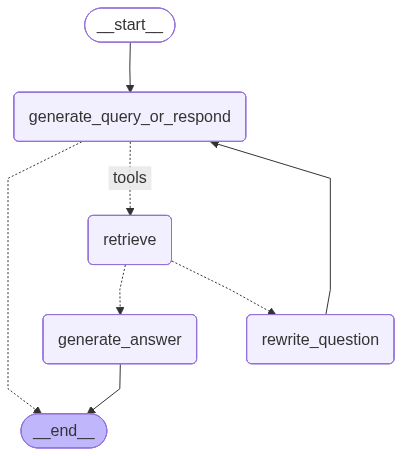

In [75]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [76]:
collection.query(
    query_texts=["first query", "second query"],
    where={"cause_num": "149/4141/24"}
)

{'ids': [['doc_0'], ['doc_0']],
 'distances': [[0.8949396], [0.8612064]],
 'embeddings': None,
 'metadatas': [[{'category_code': 40356.0,
    'start_index': 0,
    'court_code': 227,
    'cause_num': '149/4141/24',
    'adjudication_date': '2025-01-02 00:00:00+02',
    'judge': 'Олійник І. В.',
    'status': 1,
    'justice_kind': 1.0}],
  [{'adjudication_date': '2025-01-02 00:00:00+02',
    'judge': 'Олійник І. В.',
    'category_code': 40356.0,
    'start_index': 0,
    'cause_num': '149/4141/24',
    'justice_kind': 1.0,
    'court_code': 227,
    'status': 1}]],
 'documents': [['Справа № 149/4141/24\nПровадження №2/149/196/25 \nНомер рядка звіту 48\n УХВАЛА \n"02" січня 2025 р. м. Хмільник\nСуддя Хмільницького міськрайонного суду Вінницької області Олійник І. В., перевіривши матеріали справи за позовом Державної екологічної інспекції у Вінницькій області, третя особа, яка не заявляє самостійних вимог щодо предмета спору на стороні позивача: Уланівська сільська рада Хмільницького ра

In [82]:
# graph.invoke("Хто суддя в справі №712/870/25?")
# "збери в один документ всі шматки тексту по справі 149/4141/24 ідай саммері в декілька речень"
#  "збери в один документ всі шматки тексту по справі 149/4141/24 ідай саммері в декілька речень, щоб це зробити в метаданих є поле cause_num  відфільтруй по ньому і зроби саммері"
## "пошукай в базі судові рішення по місту Львів? порахуй скільки справ по всім судам по львову"

for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "пошукай в базі судові рішення по місту Київ? порахуй скільки справ по всім судам по Києву",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  chroma_get_documents (call_HkAgIT6E4UtyRgaFaEOr6lsE)
 Call ID: call_HkAgIT6E4UtyRgaFaEOr6lsE
  Args:
    where: None
    where_document: {'$contains': 'Київ'}
    include: ['documents', 'metadatas']
    limit: 100000
    offset: 0



Update from node retrieve
================================= Tool Message =================================
Name: chroma_get_documents

{"ids": ["doc_22", "doc_37", "doc_41", "doc_43", "doc_45", "doc_49", "doc_52", "doc_67", "doc_75", "doc_84", "doc_97", "doc_102", "doc_104", "doc_105", "doc_121", "doc_132", "doc_142", "doc_147", "doc_176", "doc_177", "doc_178", "doc_179", "doc_198", "doc_205", "doc_214", "doc_215", "doc_236", "doc_241"], "embeddings": null, "metadatas": [{"justice_kind": 1.0, "adjudication_date": "2025-05-23 00:00:00+03", "cause_num": "130/3187/24", "judge": "Грушковська Л. Ю.", "status": 1, "start_index

In [1]:
from google import genai
from google.genai import types
import time
from dotenv import load_dotenv

load_dotenv()


client = genai.Client()

In [ ]:
file_search_store = client.file_search_stores.create(
    config={"display_name": "fda-drug-labels"}
)
print(f"Created store: {file_search_store.name}")

Created store: fileSearchStores/fdadruglabels-m2jnwff2bt1z


In [15]:
# op = client.file_search_stores.upload_to_file_search_store(
#     file_search_store_name=file_search_store.name,
#     file="../chroma/data/20b931890171303c19f30ef27a85948f.rtf",
#     config=types.UploadToFileSearchStoreConfig(
#         mime_type="text/rtf",
#         display_name="20b931890171303c19f30ef27a85948f.rtf",
#     ),
# )
import os
import glob


DATA_DIR = "../chroma/data/*.rtf"

files = sorted(glob.glob(DATA_DIR))
print(f"Found {len(files)} RTF files")

results = []

for path in files:
    abs_path = os.path.abspath(path)
    filename = os.path.basename(path)

    try:
        op = client.file_search_stores.upload_to_file_search_store(
            file_search_store_name=file_search_store.name,
            file=abs_path,
            config=types.UploadToFileSearchStoreConfig(
                mime_type="text/rtf",
                display_name=filename,
            ),
        )
        results.append((filename, "OK"))
        print(f"✅ Uploaded: {filename}")

    except Exception as e:
        results.append((filename, str(e)))
        print(f"❌ Failed: {filename} → {e}")

print("\nSummary:")
for r in results:
    print(r)


Found 5 RTF files
✅ Uploaded: 20b931890171303c19f30ef27a85948f.rtf
✅ Uploaded: 270b13aecb633a77188ca934e7d2d1a6.rtf
✅ Uploaded: 5821cb1723e503bb832c0242c2077ddf.rtf
✅ Uploaded: 5981b74f3ce7b3d2233457edf81962a2.rtf
✅ Uploaded: 90134cf5ded1d1df3e299b715f0fdeff.rtf

Summary:
('20b931890171303c19f30ef27a85948f.rtf', 'OK')
('270b13aecb633a77188ca934e7d2d1a6.rtf', 'OK')
('5821cb1723e503bb832c0242c2077ddf.rtf', 'OK')
('5981b74f3ce7b3d2233457edf81962a2.rtf', 'OK')
('90134cf5ded1d1df3e299b715f0fdeff.rtf', 'OK')


In [18]:
# № 
query1 = "знайди справи по Кредит капітал позивачу, які його основні претензії і до кого?"

response1 = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=query1,
    config=types.GenerateContentConfig(
        tools=[
            types.Tool(
                file_search=types.FileSearch(
                    file_search_store_names=[file_search_store.name]
                )
            )
        ]
    ),
)

print(response1.text)

На підставі наданих документів, ось деякі справи, де "Кредит Капітал" є позивачем, їхні основні претензії та до кого вони звернені:

**Справи та претензії:**

*   **Справа про стягнення заборгованості за кредитним договором:**
    *   **Суть претензії:** Стягнення кредитних коштів у сумі 6000,00 грн, перерахованих 03.12.2022 року на картковий рахунок відповідача. Це було зроблено відповідно до пункту 1.1 Договору, укладеного за допомогою ТОВ "Фінансова Компанія "Лінеура Україна" та ТОВ "Кредит-Капітал" через Веб-сайт або мобільний додаток "Credit7". Електронна ідентифікація клієнта здійснюється при вході в Особистий кабінет відповідно до Закону України "Про електронну комерцію".
    *   **Відповідач:** Особа, яка отримала кредитні кошти на картковий рахунок.

*   **Справа про факторинг:**
    *   **Суть претензії:** 13 вересня 2023 року між ТОВ "Лінеура Україна" та ТОВ "ФК "Кредит-Капітал" було укладено договір факторингу №КККЛУ-13092023. Згідно з умовами цього договору, ТОВ "Лінеура У

In [ ]:



for c_text in all_texts:
    operation = client.file_search_stores.upload_to_file_search_store(
        file=pdf_file,
        file_search_store_name=file_search_store.name,
        config={"display_name": pdf_file.replace(".pdf", "")},
    )

    # Wait for indexing to complete
    while not operation.done:
        time.sleep(3)
        operation = client.operations.get(operation)

    print(f"{pdf_file} indexed")

['Справа № 149/4141/24\nПровадження №2/149/196/25 \nНомер рядка звіту 48\n УХВАЛА \n"02" січня 2025 р. м. Хмільник\nСуддя Хмільницького міськрайонного суду Вінницької області Олійник І. В., перевіривши матеріали справи за позовом Державної екологічної інспекції у Вінницькій області, третя особа, яка не заявляє самостійних вимог щодо предмета спору на стороні позивача: Уланівська сільська рада Хмільницького району Вінницької області до ОСОБА_1 про відшкодування шкоди, завданої державі внаслідок порушення природоохоронного законодавства,\nВСТАНОВИВ: До Хмільницького міськрайонного суду Вінницької області надійшла вказана позовна заява.\nДослідивши матеріали, суддя дійшов висновку про передачу її за підсудністю, з огляду на наступне.\nЗгідно із ч. 1 ст. 27 ЦПК України позови до фізичної особи пред`являються в суд за зареєстрованим у встановленому законом порядку місцем її проживання або перебування, якщо інше не передбачено законом.\nВідповідно до інформації з Єдиного державного демографі